# Black–Scholes Model and Derivative Pricing


The objective of this notebook is to study the pricing and hedging of
derivative contracts in the **Black–Scholes framework**.

A derivative is a financial contract whose value depends on an underlying
asset, typically a stock. In the Black–Scholes model, the stock price is
assumed to follow a **geometric Brownian motion**

$$
dS_t = \mu S_t\,dt + \sigma S_t\,dB_t,
$$

where:

- $S_t$ is the stock price at time $t$,
- $\mu$ is the expected return,
- $\sigma$ is the volatility,
- $B_t$ is a standard Brownian motion.

The main goal is to determine the **fair price** of a derivative and to
understand how the associated risk can be **hedged**.

### Contingent claims

A general derivative payoff can be represented by a **contingent claim**.
A contingent claim with maturity $T$ is a random variable $X$ representing
the amount paid to the holder at time $T$.

The payoff may depend on the stock price at maturity or, more generally, on
the entire stock-price path before maturity.

For example, a European call option with strike $K$ has payoff

$$
X = (S_T-K)^+ = \max(S_T-K,0),
$$

while a European put has payoff

$$
X = (K-S_T)^+ = \max(K-S_T,0).
$$

This framework also includes more exotic derivatives such as:

- Asian options, whose payoff depends on an average stock price;
- Barrier options, whose payoff depends on whether the stock crosses a
  prescribed barrier;
- Chooser options, where the holder chooses between different payoff
  structures.

For instance, an up-and-out call with strike $K$ and barrier $b>K$ can be
written as

$$
X=(S_T-K)^+
\mathbf{1}_{\left\{\sup_{0\leq t\leq T}S_t<b\right\}}.
$$

The option therefore pays the usual call payoff provided that the stock
price never reaches the barrier.

### Objective

The central question of this notebook is therefore:

$$
\boxed{\text{How can we determine the fair price of a contingent claim?}}
$$

We will use the Black–Scholes model to derive the pricing framework,and obtain the famous
Black–Scholes formula for European call and put options.

We will also study the corresponding **hedging strategy**, showing how a
derivative can be replicated dynamically using the underlying stock and a
risk-free asset.

The notebook will combine the theoretical results with numerical
experiments and simulations to illustrate the Black–Scholes model in
practice.

# From One-Period Markets to Risk-Neutral Pricing

Before considering a continuous-time model such as geometric Brownian motion, it is useful to first understand the basic idea of derivative pricing in a **one-period market**.

Consider a market with two possible dates, $t=0$ and $t=T$. At time $0$, the stock has price $S_0$. At maturity $T$, the stock can take two possible values:

$$
S_T =
\begin{cases}
S_u, & \text{with probability } p,\
S_d, & \text{with probability } 1-p, S_u>S_d
\end{cases}
$$


We also assume the existence of a risk-free asset with initial value $1$ and interest rate $r$. Thus,

$$
B_0=1,
\qquad
B_T=1+r.
$$

### The value of a portfolio

Consider a portfolio consisting of:

* $a$ units of the stock;
* $b$ units of the risk-free asset.

The value of this portfolio at time $0$ is

$$
H(0)=aS_0+b,
$$

while at maturity its value depends on the state of the market:

$$
H(T)=
\begin{cases}
aS_u+b(1+r), & \text{if the stock goes up},
aS_d+b(1+r), & \text{if the stock goes down}.
\end{cases}
$$

The portfolio $(a,b)$ therefore generates two possible terminal payoffs.

### Replicating a contingent claim

Now suppose that we want to price a contingent claim $X$ whose payoff at time $T$ is

$$
X=
\begin{cases}
X_u, & \text{if the stock goes up},\
X_d, & \text{if the stock goes down}.
\end{cases}
$$

Assuming the market is **complete**, we can find a portfolio $(a,b)$ whose terminal value exactly matches the claim:

$$
H(T)=X.
$$

This means that $a$ and $b$ must satisfy

$$
aS_u+b(1+r)=X_u,
$$

and

$$
aS_d+b(1+r)=X_d.
$$

This system has the solution

$$
a=\frac{X_u-X_d}{S_u-S_d},
$$

and

$$
b=\frac{S_uX_d-S_dX_u}
{(S_u-S_d)(1+r)}.
$$

The portfolio $H$ is called a **replicating portfolio** because it produces exactly the same payoff as the claim at maturity.

Since the two positions have identical payoffs at time $T$, the **no-arbitrage principle** implies that they must have the same price at time $0$:

$$
\boxed{P(0)=H(0)=aS_0+b.}
$$

Otherwise, one could buy the cheaper position and sell the more expensive one, generating an arbitrage opportunity.

---

### Risk-neutral pricing

There is another, extremely useful way to express the same price.

We introduce a new probability measure, denoted by $\mathbb{Q}$, called the **risk-neutral probability measure**. It is generally different from the real-world probability measure $\mathbb{P}$.

Under the real-world measure $\mathbb{P}$, probabilities describe what we believe about how the stock will actually evolve. They incorporate investors' risk preferences and the expected return of the stock.

The risk-neutral measure $\mathbb{Q}$ has a different purpose. It is constructed so that, after discounting, asset prices behave like martingales. In particular,

$$
S_0=\frac{1}{1+r}\mathbb{E}_{\mathbb{Q}}[S_T].
$$

In the one-period binomial model, the risk-neutral probability $q$ of an upward movement is determined by

$$
qS_u+(1-q)S_d=(1+r)S_0,
$$

which gives

$$
\boxed{
q=\frac{(1+r)S_0-S_d}{S_u-S_d}.
}
$$

Notice that $q$ does **not** necessarily equal the actual probability $p$ of an upward movement.

The remarkable consequence is that the price of any replicable claim can be written as its **discounted expected payoff under the risk-neutral measure**:

$$
\boxed{
P(0)=\frac{1}{1+r}\mathbb{E}_{\mathbb{Q}}[X].
}
$$

Indeed,

$$
\mathbb{E}_{\mathbb{Q}}[X]
=qX_u+(1-q)X_d,
$$

so that

$$
P(0)
=

\frac{qX_u+(1-q)X_d}{1+r}.
$$

This is exactly the same price obtained from the replicating portfolio.

The important point is therefore that we do **not** need to know the actual probabilities of the future states in order to price a derivative. Under the assumptions of no arbitrage and market completeness, we can instead use a risk-neutral probability measure.

---

## One-Period Model ---> Black–Scholes

The next step is to generalize these considerations to a market where the
stock is modelled by geometric Brownian motion. The reason for doing this
is of course that the one-period market model is very unrealistic, and to have
confidence in the derived prices we need to base our findings on models which
are close to real market behaviour. 


# The Black–Scholes Market

We now move from the one-period market to a **continuous-time financial
market**. The main idea remains the same: we want to determine the fair
price of a contingent claim by constructing a portfolio that replicates its
payoff.

The key difference is that the underlying stock can now evolve continuously
over time.

## 1. The financial market

We consider a market consisting of three assets:

1. a risky asset, represented by a stock;
2. a risk-free asset, represented by a bank account;
3. a contingent claim that we want to price and hedge.

### The stock

The stock price process $S(t)$ is assumed to follow a **geometric Brownian
motion**:

$$
dS(t)=\alpha S(t),dt+\sigma S(t),dB(t),
$$

where:

* $\alpha$ is the drift of the stock;
* $\sigma>0$ is its volatility;
* $B(t)$ is a standard Brownian motion.

The parameter $\alpha$ describes the expected growth rate of the stock under
the real-world probability measure $\mathbb{P}$, while $\sigma$ measures the
uncertainty in its evolution.

Equivalently, the solution of this stochastic differential equation is

$$
S(t)
=

S(0)
\exp\left[
\left(\alpha-\frac12\sigma^2\right)t
+\sigma B(t)
\right].
$$

### The risk-free asset

The second asset is the risk-free bank account. Its value is denoted by
$R(t)$ and satisfies

$$
R(t)=e^{rt},
$$

where $r$ is the constant continuously compounded risk-free interest rate.

Consequently,

$$
dR(t)=rR(t),dt.
$$

We normalize the initial value to

$$
R(0)=1.
$$

---

## 2. The contingent claim

Let $X$ be a contingent claim with maturity $T$. It represents the amount
that the holder receives at time $T$.

We denote by $P(t)$ the price of the claim at time $t$. Our objective is to
determine the process $P(t)$ consistently with the no-arbitrage condition.

At maturity, the claim must satisfy

$$
P(T)=X.
$$

In particular, later we will focus on claims of the form

$$
X=f(S(T)),
$$

which include standard European call and put options.

The central problem is therefore to determine the process $P(t)$ and, at the
same time, find a trading strategy capable of reproducing the payoff $X$.

---

## 3. Portfolios and their value

At each time $t$, an investor holds a portfolio described by

$$
(a(t),b(t),c(t)),
$$

where:

* $a(t)$ is the number of units of the stock;
* $b(t)$ is the amount invested in the risk-free asset;
* $c(t)$ is the number of units of the contingent claim.

The value of the portfolio is therefore

$$
V(t)
=

a(t)S(t)+b(t)R(t)+c(t)P(t).
$$

The quantities $a(t)$, $b(t)$ and $c(t)$ are allowed to vary with time and
represent a **trading strategy**.

Since the portfolio is continuously rebalanced, we need to specify how this
rebalancing is financed. This leads to the important concept of a
self-financing strategy.

---

## 4. Self-financing strategies

A trading strategy is called **self-financing** if, after the initial
investment, no additional money is injected into or withdrawn from the
portfolio.

In other words, changes in the composition of the portfolio must be
financed entirely by exchanging the assets already held.

If

$$
V(t)=a(t)S(t)+b(t)R(t)+c(t)P(t),
$$

then for a self-financing strategy the change in the portfolio value is

$$
\boxed{
dV(t)
=

a(t),dS(t)
+
b(t),dR(t)
+
c(t),dP(t).
}
$$

There are no additional terms involving $da(t)$, $db(t)$ or $dc(t)$.

This is important. Although the quantities of each asset may change over
time, these changes correspond only to exchanging one asset for another
inside the portfolio. They do not represent external cash flows.

For example, increasing the number of shares of the stock requires selling
some of the other assets in the portfolio. The total wealth therefore
changes only because the prices of the assets change.


---

## 5. The hedging problem

The fundamental objective is now to construct a **self-financing portfolio**
that reproduces the payoff of the contingent claim.

Suppose that the claim has payoff $X$ at time $T$. We seek a strategy

$$
H(t)=\big(a(t),b(t),c(t)\big)
$$

such that its value process satisfies

$$
V^H(t)
=

a(t)S(t)+b(t)R(t)+c(t)P(t),
$$

and, at maturity,

$$
\boxed{
V^H(T)=X.
}
$$

Such a portfolio is called a **replicating portfolio** or **hedging
portfolio**.

The hedging problem can therefore be summarized as finding a self-financing
strategy $H$ satisfying

$$
\boxed{
\begin{cases}
H(t)=\big(a(t),b(t),c(t)\big),
V^H(t)=a(t)S(t)+b(t)R(t)+c(t)P(t),
dV^H(t)=a(t)dS(t)+b(t)dR(t)+c(t)dP(t),
V^H(T)=X.
\end{cases}
}
$$

The final condition is the essential one: the portfolio must generate
exactly the same cash flow as the claim at maturity.

---

## 6. Assumptions

As in the one-period model, two fundamental assumptions will be imposed.

### No arbitrage

We assume that the market is **free of arbitrage**.

Informally, this means that there is no trading strategy which starts with
zero initial wealth, has no possibility of loss, and has a strictly positive
probability of generating a positive profit.

This assumption is what allows us to assign a unique economically meaningful
price to a replicable claim.

### Completeness

We also assume that the Black–Scholes market is **complete**.

Completeness means that every contingent claim satisfying the appropriate
integrability conditions can be replicated by a self-financing trading
strategy involving the traded assets.

In particular, for a claim $X$, there exists a self-financing strategy $H$
such that

$$
V^H(T)=X.
$$

Under the combination of **no arbitrage and completeness**, the claim has a
unique arbitrage-free price.

This is the continuous-time analogue of the complete one-period binomial
market discussed previously.

---

## 7. Objective

We are now ready to address the central problem of the Black–Scholes model.

Given a contingent claim $X$, we want to:

1. determine its price process $P(t)$;
2. construct a self-financing strategy that replicates its payoff;
3. determine the initial value $P(0)$ required by the no-arbitrage
   condition.

The first class of claims we will study consists of claims of the form

$$
\boxed{
X=f(S(T)).
}
$$

This includes the standard European call and put options:

$$
X_{\mathrm{call}}=(S(T)-K)^+,
$$

and

$$
X_{\mathrm{put}}=(K-S(T))^+.
$$

The next section will develop the **pricing and hedging of claims of the
form $X=f(S(T))$** and will lead to the Black–Scholes pricing equation and,
ultimately, the Black–Scholes formula.


# Pricing and Hedging of Claims of the Form $X=f(S(T))$

We now consider contingent claims whose payoff depends only on the stock
price at maturity:

$$
\boxed{X=f(S(T)).}
$$

We assume that

$$
\mathbb{E}[X^2]<\infty,
$$

which ensures that the claim satisfies the required integrability
conditions.

The objective is to determine both:

- the price process $P(t)$ of the claim;
- the self-financing strategy that replicates its payoff.

Since the claim depends on the stock price, we look for a price process of
the form

$$
\boxed{P(t)=C(t,S(t))}
$$

for some deterministic function

$$
C:[0,T]\times\mathbb{R}_+\rightarrow\mathbb{R}.
$$

Our goal is therefore to determine the function $C(t,x)$.

---

## 1. Derivation of the Black--Scholes PDE

### Applying Itô's formula

Recall that the stock follows the geometric Brownian motion

$$
dS(t)=\alpha S(t)\,dt+\sigma S(t)\,dB(t).
$$

Since

$$
P(t)=C(t,S(t)),
$$

we can apply **Itô's formula** to obtain the dynamics of the claim price:

$$
dP(t)
=
\frac{\partial C}{\partial t}(t,S(t))\,dt
+
\frac{\partial C}{\partial x}(t,S(t))\,dS(t)
+
\frac12
\frac{\partial^2 C}{\partial x^2}(t,S(t))
(dS(t))^2.
$$

Since

$$
(dS(t))^2=\sigma^2S(t)^2\,dt,
$$

we obtain

$$
dP(t)
=
\left[
\frac{\partial C}{\partial t}
+
\alpha S(t)\frac{\partial C}{\partial x}
+
\frac12\sigma^2S(t)^2
\frac{\partial^2C}{\partial x^2}
\right]dt
+
\sigma S(t)
\frac{\partial C}{\partial x}\,dB(t).
$$

For simplicity, all derivatives of $C$ above are evaluated at $(t,S(t))$.

Thus,

$$
\boxed{
dP(t)
=
\left(
C_t+\alpha S_tC_x+
\frac12\sigma^2S_t^2C_{xx}
\right)dt
+
\sigma S_tC_x\,dB_t.
}
$$

---

## 2. Replication of the Claim

Because we assume that the Black--Scholes market is **complete**, the
claim can be replicated by a self-financing trading strategy.

Let

$$
H(t)=\big(a_H(t),b_H(t)\big)
$$

denote the replicating strategy, where:

- $a_H(t)$ is the number of units of the stock;
- $b_H(t)$ is the number of units of the risk-free asset.

Its value is

$$
V^H(t)=a_H(t)S(t)+b_H(t)R(t).
$$

Since the strategy replicates the claim, the no-arbitrage condition implies
that the value of the replicating portfolio must equal the price of the
claim:

$$
\boxed{V^H(t)=P(t).}
$$

Therefore,

$$
dP(t)=dV^H(t).
$$

Because $H$ is self-financing,

$$
dV^H(t)
=
a_H(t)dS(t)+b_H(t)dR(t).
$$

Using

$$
dS(t)=\alpha S(t)\,dt+\sigma S(t)\,dB(t)
$$

and

$$
dR(t)=rR(t)\,dt,
$$

we obtain

$$
dP(t)
=
\left[
a_H(t)\alpha S(t)+b_H(t)rR(t)
\right]dt
+
a_H(t)\sigma S(t)\,dB(t).
$$

We now have two expressions for the same process $dP(t)$.

From Itô's formula:

$$
dP(t)
=
\left[
C_t+\alpha S_tC_x+
\frac12\sigma^2S_t^2C_{xx}
\right]dt
+
\sigma S_tC_x\,dB_t,
$$

while from the replicating portfolio:

$$
dP(t)
=
\left[
a_H\alpha S_t+b_HrR_t
\right]dt
+
a_H\sigma S_t\,dB_t.
$$

---

## 3. The Hedging Strategy

Since these two stochastic differential expressions describe the same
process, their coefficients of $dB_t$ must coincide.

Therefore,

$$
a_H(t)\sigma S(t)
=
\sigma S(t)
\frac{\partial C}{\partial x}(t,S(t)).
$$

Assuming $S(t)>0$ and $\sigma>0$, we obtain

$$
\boxed{
a_H(t)=
\frac{\partial C}{\partial x}(t,S(t)).
}
$$

This quantity is known as the **Delta** of the derivative:

$$
\boxed{
\Delta(t)=C_x(t,S(t)).
}
$$

Thus, the number of shares that must be held in the replicating portfolio is
exactly the derivative of the option price with respect to the stock price:

$$
\boxed{\text{Hedging position in stock}=\text{Delta}.}
$$

---

### Determining the position in the risk-free asset

Since

$$
P(t)=C(t,S(t))
$$

and

$$
P(t)=a_H(t)S(t)+b_H(t)R(t),
$$

we have

$$
C(t,S(t))
=
a_H(t)S(t)+b_H(t)R(t).
$$

Using

$$
a_H(t)=C_x(t,S(t)),
$$

we obtain

$$
b_H(t)R(t)
=
C(t,S(t))-S(t)C_x(t,S(t)).
$$

Hence,

$$
\boxed{
b_H(t)
=
\frac{C(t,S(t))-S(t)C_x(t,S(t))}
{R(t)}.
}
$$

Since $R(t)=e^{rt}$,

$$
\boxed{
b_H(t)
=
e^{-rt}
\left[
C(t,S(t))-S(t)C_x(t,S(t))
\right].
}
$$

We have therefore determined the replicating strategy, provided that the
function $C$ is known:

$$
\boxed{
\begin{aligned}
a_H(t)&=C_x(t,S(t)),\\[4pt]
b_H(t)&=
e^{-rt}\left[C(t,S(t))-S(t)C_x(t,S(t))\right].
\end{aligned}
}
$$

---

## 4. Derivation of the Black--Scholes PDE

We now compare the $dt$ terms.

From Itô's formula, the coefficient of $dt$ is

$$
C_t+\alpha S_tC_x+
\frac12\sigma^2S_t^2C_{xx}.
$$

From the replicating portfolio, it is

$$
a_H\alpha S_t+b_HrR_t.
$$

Using

$$
a_H=C_x
$$

and

$$
b_HR_t=C-S_tC_x,
$$

we obtain

$$
C_t+\alpha S_tC_x+
\frac12\sigma^2S_t^2C_{xx}
=
\alpha S_tC_x+r(C-S_tC_x).
$$

Expanding the right-hand side:

$$
C_t+\alpha S_tC_x+
\frac12\sigma^2S_t^2C_{xx}
=
\alpha S_tC_x+rC-rS_tC_x.
$$

The terms involving $\alpha$ cancel:

$$
C_t+rS_tC_x+
\frac12\sigma^2S_t^2C_{xx}
=
rC.
$$

Replacing $S(t)$ by a generic state variable $x$, we obtain the
**Black--Scholes partial differential equation**:

$$
\boxed{
\frac{\partial C}{\partial t}
+
rx\frac{\partial C}{\partial x}
+
\frac12\sigma^2x^2
\frac{\partial^2C}{\partial x^2}
=
rC.
}
$$



The pricing problem is consequently reduced to the following terminal value
problem:

$$
\boxed{
\begin{cases}
\displaystyle
C_t+rxC_x+\frac12\sigma^2x^2C_{xx}=rC,
& (t,x)\in[0,T)\times\mathbb{R}_+,\\[8pt]
C(T,x)=f(x),
& x\geq0.
\end{cases}
}
$$

---

An important observation is that the parameter $\alpha$, which describes
the expected return of the stock under the real-world probability measure,
has completely disappeared from the pricing equation.

This is a consequence of **no-arbitrage and replication**.

The derivative price does not depend on the investor's expected return on
the stock.

This is one of the fundamental insights of the Black--Scholes framework.

---

Furthermore, since the replicating strategy is given by

$$
a_H(t)=C_x(t,S(t))
$$

and

$$
b_H(t)=
e^{-rt}
\left[
C(t,S(t))-S(t)C_x(t,S(t))
\right].
$$

In particular, the stock position

$$
a_H(t)=C_x(t,S(t))
$$

generally changes continuously with time because $S(t)$ changes continuously.

Thus, in the idealized Black--Scholes model, the portfolio must be
**continuously rebalanced** in order to remain perfectly hedged.

In practice, continuous trading is impossible. Moreover, buying and selling
the underlying asset generates **transaction costs**, which are not included
in the classical Black--Scholes model.

The Black--Scholes framework therefore represents an idealized frictionless
market in which continuous rebalancing is possible and costless.

---

## 5. Conclusion

We have now transformed the pricing and hedging problem into a mathematical
problem:

$$
\boxed{
\text{Find }C(t,x)\text{ satisfying the Black--Scholes PDE and }
C(T,x)=f(x).
}
$$

Once $C$ is known, the hedging strategy follows immediately from

$$
a_H(t)=C_x(t,S(t))
$$

and

$$
b_H(t)=
e^{-rt}
\left[
C(t,S(t))-S(t)C_x(t,S(t))
\right].
$$

The next subsection will therefore focus on **solving the Black--Scholes
PDE** and obtaining an explicit pricing formula for European options.

# Solution of the Black--Scholes PDE

We have derived the Black--Scholes PDE

$$
\boxed{
C_t+rxC_x+\frac12\sigma^2x^2C_{xx}=rC
}
$$

with terminal condition

$$
\boxed{C(T,x)=f(x).}
$$

We now want to find an explicit representation of the solution $C(t,x)$.

The key idea is to introduce a geometric Brownian motion whose drift is the
risk-free rate $r$ and apply Itô's formula to $C(t,Z_t)$. This will show that
the discounted process $e^{-rt}C(t,Z_t)$ is a martingale, which directly gives
the desired expectation representation.

---

## 1. Risk-neutral geometric Brownian motion

Recall that under the real-world probability measure $\mathbb{P}$, the stock
price satisfies

$$
dS(t)=\alpha S(t)\,dt+\sigma S(t)\,dB(t).
$$

We now introduce a new process $Z(t)$ satisfying

$$
\boxed{
dZ(t)=rZ(t)\,dt+\sigma Z(t)\,dB(t).
}
$$

The only difference with the stock dynamics is that the drift $\alpha$ has
been replaced by the risk-free rate $r$.

For a process starting at time $t$ from $Z(t)=x$, we write

$$
Z^{t,x}(s), \qquad s\geq t,
$$

with

$$
Z^{t,x}(t)=x.
$$

Its explicit solution is

$$
\boxed{
Z^{t,x}(s)
=
x\exp\left(
\left(r-\frac12\sigma^2\right)(s-t)
+
\sigma(B(s)-B(t))
\right).
}
$$

In particular,

$$
Z^{t,x}(T)
=
x\exp\left(
\left(r-\frac12\sigma^2\right)(T-t)
+
\sigma(B(T)-B(t))
\right).
$$

Thus, $Z^{t,x}(T)$ is lognormally distributed.

The reason for introducing this process will become clear by applying Itô's
formula to $C(t,Z^{t,x}(t))$.

---

## 2. Applying Itô's formula

Consider the process

$$
C(t,Z^{t,x}(t)).
$$

Applying Itô's formula gives

$$
dC(t,Z_t)
=
C_t(t,Z_t)\,dt
+
C_x(t,Z_t)\,dZ_t
+
\frac12C_{xx}(t,Z_t)(dZ_t)^2.
$$

Since

$$
dZ_t=rZ_t\,dt+\sigma Z_t\,dB_t,
$$

we have

$$
(dZ_t)^2=\sigma^2Z_t^2\,dt.
$$

Therefore,

$$
dC(t,Z_t)
=
\left[
C_t(t,Z_t)
+
rZ_tC_x(t,Z_t)
+
\frac12\sigma^2Z_t^2C_{xx}(t,Z_t)
\right]dt
+
\sigma Z_tC_x(t,Z_t)\,dB_t.
$$

But $C$ satisfies the Black--Scholes PDE:

$$
C_t+rxC_x+\frac12\sigma^2x^2C_{xx}=rC.
$$

Evaluating this equation at $x=Z_t$ gives

$$
C_t(t,Z_t)
+
rZ_tC_x(t,Z_t)
+
\frac12\sigma^2Z_t^2C_{xx}(t,Z_t)
=
rC(t,Z_t).
$$

Consequently,

$$
\boxed{
dC(t,Z_t)
=
rC(t,Z_t)\,dt
+
\sigma Z_tC_x(t,Z_t)\,dB_t.
}
$$

The important observation is that the drift of $C(t,Z_t)$ is exactly
$rC(t,Z_t)$.

---

## 3. Discounting and the pricing representation

To remove this deterministic growth at the risk-free rate, define the
discounted process

$$
Y_t=e^{-rt}C(t,Z_t).
$$

Applying the product rule,

$$
dY_t
=
d\left(e^{-rt}C(t,Z_t)\right).
$$

Since

$$
d(e^{-rt})=-re^{-rt}\,dt,
$$

we obtain

$$
dY_t
=
e^{-rt}dC(t,Z_t)
-r e^{-rt}C(t,Z_t)\,dt.
$$

Using

$$
dC(t,Z_t)
=
rC(t,Z_t)\,dt
+
\sigma Z_tC_x(t,Z_t)\,dB_t,
$$

we get

$$
dY_t
=
e^{-rt}
\left[
rC(t,Z_t)\,dt
+
\sigma Z_tC_x(t,Z_t)\,dB_t
\right]
-r e^{-rt}C(t,Z_t)\,dt.
$$

The two drift terms cancel:

$$
\boxed{
dY_t
=
e^{-rt}\sigma Z_tC_x(t,Z_t)\,dB_t.
}
$$

Under the appropriate integrability conditions, the stochastic integral has
zero expectation. Hence $Y_t$ is a martingale.

Therefore, for $t\leq T$,

$$
Y_t
=
\mathbb{E}
\left[
Y_T\mid\mathcal{F}_t
\right].
$$

Substituting the definition of $Y_t$ gives

$$
e^{-rt}C(t,Z_t)
=
\mathbb{E}
\left[
e^{-rT}C(T,Z_T)
\mid\mathcal{F}_t
\right].
$$

At maturity, the terminal condition is

$$
C(T,x)=f(x),
$$

so that

$$
C(T,Z_T)=f(Z_T).
$$

Therefore,

$$
e^{-rt}C(t,Z_t)
=
\mathbb{E}
\left[
e^{-rT}f(Z_T)
\mid\mathcal{F}_t
\right].
$$

Multiplying by $e^{rt}$,

$$
\boxed{
C(t,Z_t)
=
e^{-r(T-t)}
\mathbb{E}
\left[
f(Z_T)
\mid\mathcal{F}_t
\right].
}
$$

If we consider the process starting from $Z_t=x$, this becomes

$$
\boxed{
C(t,x)
=
e^{-r(T-t)}
\mathbb{E}
\left[
f\left(Z^{t,x}(T)\right)
\right].
}
$$

This gives the desired representation of the solution of the
Black--Scholes PDE.

---

### Interpretation

The solution can therefore be interpreted as follows:

1. Start from the current stock price $x$ at time $t$.
2. Evolve the stock according to the geometric Brownian motion

$$
dZ_s=rZ_s\,ds+\sigma Z_s\,dB_s.
$$

3. Evaluate the payoff $f(Z_T)$ at maturity.
4. Take its expectation.
5. Discount the expected payoff at the risk-free rate.

Thus,

$$
\boxed{
\text{Price at time }t
=
\text{discounted expected payoff under risk-neutral dynamics}.
}
$$

The drift $\alpha$ of the real-world stock dynamics does not appear in this
expression. Instead, the process used for pricing has drift $r$.

This is the mathematical origin of **risk-neutral pricing** in the
Black--Scholes model.

---

## 4. Price and Hedging Strategy

We have obtained the solution

$$
\boxed{
C(t,x)
=
e^{-r(T-t)}
\mathbb{E}
\left[
f\left(Z^{t,x}(T)\right)
\right].
}
$$

Therefore, the price of the contingent claim is

$$
\boxed{
P(t)=C(t,S(t)).
}
$$

Once $C$ is known, the replicating strategy follows from the results of the
previous section.

The number of units of the stock is

$$
\boxed{
a_H(t)
=
\frac{\partial C}{\partial x}(t,S(t)).
}
$$

This is the **Delta** of the claim.

The number of units of the risk-free asset is

$$
\boxed{
b_H(t)
=
\frac{1}{R(t)}
\left[
C(t,S(t))
-
S(t)\frac{\partial C}{\partial x}(t,S(t))
\right].
}
$$

Since

$$
R(t)=e^{rt},
$$

we can also write

$$
\boxed{
b_H(t)
=
e^{-rt}
\left[
C(t,S(t))
-
S(t)C_x(t,S(t))
\right].
}
$$

Thus, solving the Black--Scholes PDE gives us both the **price** of the
claim and its **replicating hedging strategy**.

---


# The Black--Scholes Formula for Call Options

We now apply the pricing formula derived in the previous section to a European
call option.

Consider a call option with strike price $K$ and maturity $T$. Its payoff is

$$
X=(S(T)-K)^+ = \max(S(T)-K,0).
$$

The payoff function is therefore

$$
f(x)=(x-K)^+.
$$

From the previous section, the price of the claim is

$$
C(t,x)
=
e^{-r(T-t)}
\mathbb E
\left[
f\left(Z^{t,x}(T)\right)
\right],
$$

where $Z^{t,x}$ follows the risk-neutral dynamics

$$
dZ_s=rZ_s\,ds+\sigma Z_s\,dB_s,
\qquad
Z_t=x.
$$

Its explicit solution is

$$
Z^{t,x}(T)
=
x\exp\left(
\left(r-\frac12\sigma^2\right)(T-t)
+
\sigma(B_T-B_t)
\right).
$$

### 1. Derivation of the Black--Scholes Formula

Since

$$
B_T-B_t \sim \mathcal N(0,T-t),
$$

we may write

$$
B_T-B_t=\sqrt{T-t}\,Y,
\qquad
Y\sim\mathcal N(0,1).
$$

Hence,

$$
Z^{t,x}(T)
=
x\exp\left(
\left(r-\frac12\sigma^2\right)(T-t)
+
\sigma\sqrt{T-t}\,Y
\right).
$$

The option price becomes

$$
C(t,x)
=
e^{-r(T-t)}
\mathbb E
\left[
\left(
x e^{(r-\frac12\sigma^2)(T-t)+\sigma\sqrt{T-t}Y}
-K
\right)^+
\right].
$$

Let

$$
\tau=T-t.
$$

The payoff is positive whenever

$$
x e^{(r-\frac12\sigma^2)\tau+\sigma\sqrt{\tau}Y}>K.
$$

Taking logarithms,

$$
Y>
\frac{\ln(K/x)-\left(r-\frac12\sigma^2\right)\tau}
{\sigma\sqrt{\tau}}.
$$

Define

$$
\boxed{
d_2
=
\frac{
\ln(x/K)
+
\left(r-\frac12\sigma^2\right)\tau
}
{\sigma\sqrt{\tau}}
}
$$

so that the condition becomes

$$
Y>-d_2.
$$

Therefore,

$$
C(t,x)
=
e^{-r\tau}
\left[
\mathbb E
\left(
Z^{t,x}(T)\mathbf 1_{\{Y>-d_2\}}
\right)
-
K\mathbb P(Y>-d_2)
\right].
$$

Since $Y$ is standard normal,

$$
\mathbb P(Y>-d_2)=\Phi(d_2),
$$

where $\Phi$ denotes the cumulative distribution function of a standard
normal random variable.

For the first term,

$$
\mathbb E
\left(
Z^{t,x}(T)\mathbf 1_{\{Y>-d_2\}}
\right)
=
x e^{(r-\frac12\sigma^2)\tau}
\int_{-d_2}^{\infty}
e^{\sigma\sqrt{\tau}y}\phi(y)\,dy,
$$

where

$$
\phi(y)=\frac1{\sqrt{2\pi}}e^{-y^2/2}
$$

is the standard normal density.

Completing the square,

$$
e^{\sigma\sqrt{\tau}y}\phi(y)
=
e^{\frac12\sigma^2\tau}
\phi(y-\sigma\sqrt{\tau}).
$$

Thus,

$$
\int_{-d_2}^{\infty}
e^{\sigma\sqrt{\tau}y}\phi(y)\,dy
=
e^{\frac12\sigma^2\tau}
\int_{-d_2-\sigma\sqrt{\tau}}^\infty
\phi(z)\,dz.
$$

Define

$$
\boxed{
d_1=d_2+\sigma\sqrt{\tau}
}
$$

or equivalently

$$
\boxed{
d_1
=
\frac{
\ln(x/K)
+
\left(r+\frac12\sigma^2\right)\tau
}
{\sigma\sqrt{\tau}}
}.
$$

Using the symmetry of the normal distribution,

$$
\int_{-d_1}^{\infty}\phi(z)\,dz
=
\Phi(d_1).
$$

Hence,

$$
\mathbb E
\left(
Z^{t,x}(T)\mathbf 1_{\{Y>-d_2\}}
\right)
=
x e^{r\tau}\Phi(d_1).
$$

Substituting back,

$$
C(t,x)
=
e^{-r\tau}
\left[
x e^{r\tau}\Phi(d_1)
-
K\Phi(d_2)
\right].
$$

We obtain the celebrated Black--Scholes formula:

$$
\boxed{
C(t,x)
=
x\Phi(d_1)
-
Ke^{-r(T-t)}\Phi(d_2).
}
$$

Replacing $x$ by the current stock price $S(t)$ gives

$$
\boxed{
P(t)
=
S(t)\Phi(d_1)
-
Ke^{-r(T-t)}\Phi(d_2),
}
$$

where

$$
d_1
=
\frac{
\ln\left(\frac{S(t)}{K}\right)
+
\left(r+\frac12\sigma^2\right)(T-t)
}
{\sigma\sqrt{T-t}}
$$

and

$$
d_2
=
\frac{
\ln\left(\frac{S(t)}{K}\right)
+
\left(r-\frac12\sigma^2\right)(T-t)
}
{\sigma\sqrt{T-t}}.
$$

Notice that the stock drift $\alpha$ does not appear in the formula. The
option price depends only on the current stock price, volatility, strike,
interest rate and time to maturity.

---

### 2. Hedging of a Call Option

From the previous section, the number of shares in the replicating portfolio is

$$
a_H(t)
=
\frac{\partial C}{\partial x}(t,S(t)).
$$

Differentiating the Black--Scholes formula with respect to $x$ gives

$$
\boxed{
a_H(t)=\Phi(d_1).
}
$$

This quantity is known as the **Delta** of the call option:

$$
\boxed{
\Delta_{\text{call}}
=
\Phi(d_1).
}
$$

Since $\Phi$ is a cumulative distribution function,

$$
0<\Delta_{\text{call}}<1.
$$

The position in the risk-free asset is

$$
\boxed{
b_H(t)
=
\frac{
C(t,S(t))
-
S(t)\Phi(d_1)
}
{R(t)}
}
$$

with

$$
R(t)=e^{rt}.
$$

Therefore, the complete replicating portfolio is

$$
\boxed{
\begin{aligned}
a_H(t)&=\Phi(d_1),\\[4pt]
b_H(t)&=
e^{-rt}
\left[
C(t,S(t))
-
S(t)\Phi(d_1)
\right].
\end{aligned}
}
$$

The Delta can be interpreted as the number of shares that must be held in
order to hedge one call option.

As maturity approaches, the Delta tends to

$$
\Delta
\approx
\begin{cases}
0, & S<K,\\
1, & S>K,
\end{cases}
$$

which agrees with the intuition that an in-the-money call behaves almost like
one share of stock, while an out-of-the-money call becomes nearly worthless.

---



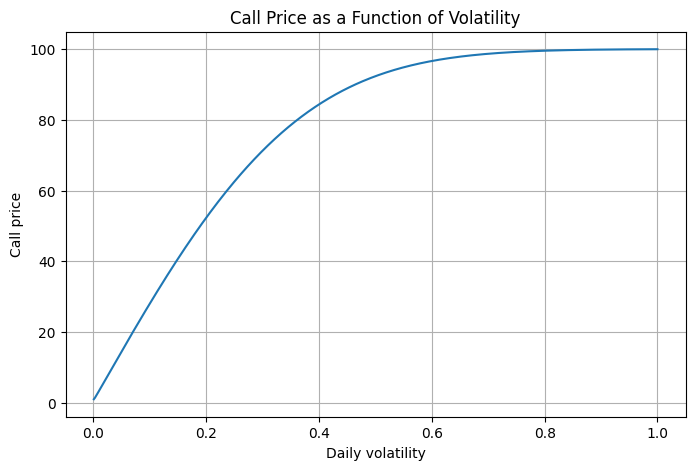

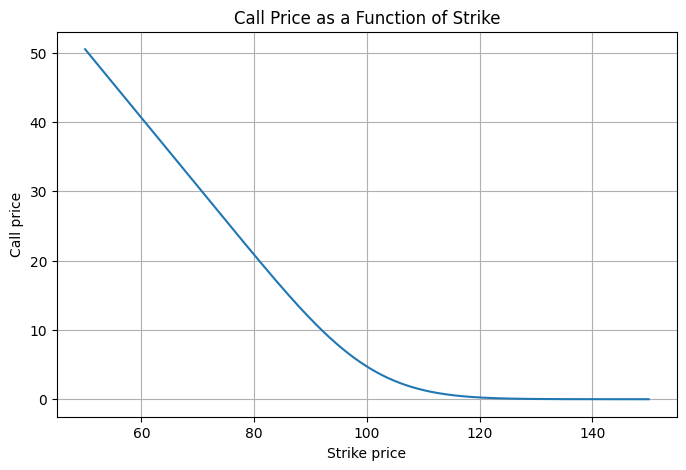

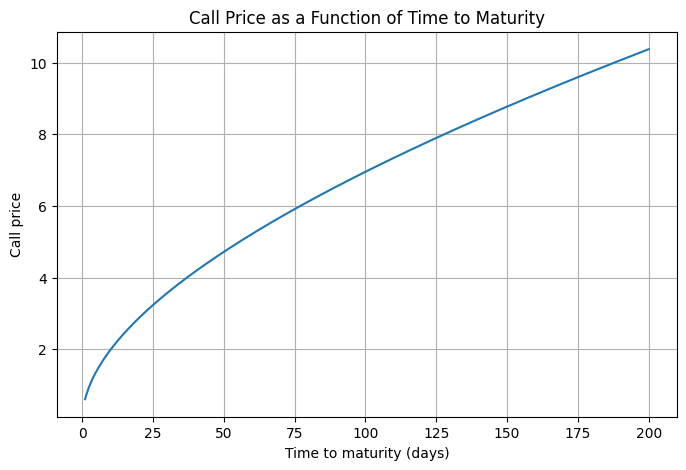

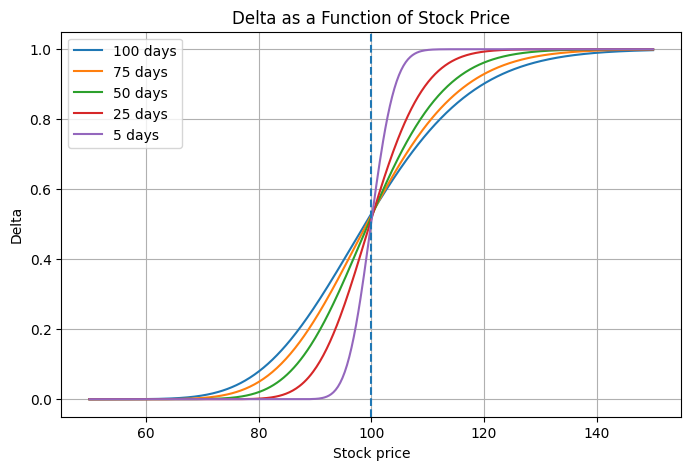

In [1]:
### 3.3 Numerical Illustration


#### Call price as a function of volatility

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def black_scholes_call(S, K, T, r, sigma):
    d1 = (
        np.log(S / K)
        + (r + 0.5 * sigma**2) * T
    ) / (sigma * np.sqrt(T))

    d2 = d1 - sigma * np.sqrt(T)

    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

S0 = 100
K = 100
T = 50
r = 0.05 / 252

sigmas = np.linspace(0.001, 1, 500)

prices = black_scholes_call(
    S=S0,
    K=K,
    T=T,
    r=r,
    sigma=sigmas
)

plt.figure(figsize=(8,5))
plt.plot(sigmas, prices)
plt.xlabel("Daily volatility")
plt.ylabel("Call price")
plt.title("Call Price as a Function of Volatility")
plt.grid(True)
plt.show()

#### Call price as a function of the strike price

S0 = 100
T = 50
sigma = 0.015
r = 0.05 / 252

strikes = np.linspace(50, 150, 500)

prices = black_scholes_call(
    S=S0,
    K=strikes,
    T=T,
    r=r,
    sigma=sigma
)

plt.figure(figsize=(8,5))
plt.plot(strikes, prices)
plt.xlabel("Strike price")
plt.ylabel("Call price")
plt.title("Call Price as a Function of Strike")
plt.grid(True)
plt.show()

#### Call price as a function of time to maturity

S0 = 100
K = 100
sigma = 0.015
r = 0.05 / 252

maturities = np.linspace(1, 200, 500)

prices = black_scholes_call(
    S=S0,
    K=K,
    T=maturities,
    r=r,
    sigma=sigma
)

plt.figure(figsize=(8,5))
plt.plot(maturities, prices)
plt.xlabel("Time to maturity (days)")
plt.ylabel("Call price")
plt.title("Call Price as a Function of Time to Maturity")
plt.grid(True)
plt.show()

#### Delta as a function of the stock price

def call_delta(S, K, T, r, sigma):
    d1 = (
        np.log(S / K)
        + (r + 0.5 * sigma**2) * T
    ) / (sigma * np.sqrt(T))

    return norm.cdf(d1)

K = 100
sigma = 0.015
r = 0.0

stock_prices = np.linspace(50, 150, 500)

times = [100, 75, 50, 25, 5]

plt.figure(figsize=(8,5))

for T in times:
    delta = call_delta(stock_prices, K, T, r, sigma)
    plt.plot(stock_prices, delta, label=f"{T} days")

plt.axvline(K, linestyle="--")
plt.xlabel("Stock price")
plt.ylabel("Delta")
plt.title("Delta as a Function of Stock Price")
plt.legend()
plt.grid(True)
plt.show()


# General Options: The Density Approach

For the call option, we obtained the hedging strategy by differentiating the
Black--Scholes formula with respect to the initial stock price. In particular,
we used the derivative of the payoff function

$$
f(x)=(x-K)^+.
$$

However, for a general contingent claim

$$
X=f(S_T),
$$

the payoff function $f$ does not necessarily have to be differentiable.

For example, consider the digital option

$$
f(x)=\mathbf 1_{\{x>K\}},
$$

which pays $1$ if the stock price is above $K$ at maturity and $0$ otherwise.
The function $f$ is not differentiable at $K$.

We therefore need another way to calculate

$$
\Delta(t,x)=\frac{\partial C}{\partial x}(t,x).
$$

The idea is to move the dependence on the initial stock price $x$ from the
payoff function to the probability density of the terminal stock price.

---

### 1. Distribution of the terminal stock price

Recall that under the risk-neutral dynamics,

$$
dZ_s=rZ_s\,ds+\sigma Z_s\,dB_s,
\qquad
Z_t=x.
$$

The solution at maturity is

$$
Z^{t,x}(T)
=
x\exp\left(
\left(r-\frac12\sigma^2\right)(T-t)
+
\sigma(B_T-B_t)
\right).
$$

Let

$$
\tau=T-t.
$$

Since

$$
B_T-B_t=\sqrt{\tau}\,Y,
\qquad
Y\sim\mathcal N(0,1),
$$

we can write

$$
Z^{t,x}(T)
=
x\exp\left(
\left(r-\frac12\sigma^2\right)\tau
+
\sigma\sqrt{\tau}\,Y
\right).
$$

Taking logarithms,

$$
\ln Z^{t,x}(T)
=
\ln x
+
\left(r-\frac12\sigma^2\right)\tau
+
\sigma\sqrt{\tau}\,Y.
$$

Define

$$
U=\ln Z^{t,x}(T).
$$

Then

$$
\boxed{
U\sim
\mathcal N
\left(
\ln x+\left(r-\frac12\sigma^2\right)\tau,
\,
\sigma^2\tau
\right).
}
$$

Let

$$
m(t,x)
=
\ln x+\left(r-\frac12\sigma^2\right)\tau.
$$

Then

$$
U\sim\mathcal N(m(t,x),\sigma^2\tau).
$$

Its density is

$$
\boxed{
p_U(y;t,x)
=
\frac{1}{\sigma\sqrt{2\pi\tau}}
\exp\left(
-\frac{(y-m(t,x))^2}{2\sigma^2\tau}
\right).
}
$$

---

### 2. Rewriting the option price

The pricing formula is

$$
C(t,x)
=
e^{-r\tau}
\mathbb E
\left[
f(Z^{t,x}(T))
\right].
$$

Since

$$
Z^{t,x}(T)=e^U,
$$

we can write the expectation using the density of $U$:

$$
\boxed{
C(t,x)
=
e^{-r\tau}
\int_{-\infty}^{\infty}
f(e^y)p_U(y;t,x)\,dy.
}
$$

This representation is particularly useful because the dependence on $x$
now appears only in the density $p_U$.

The payoff itself,

$$
f(e^y),
$$

does not explicitly depend on $x$.

This is the key idea of the density approach.

---

### 3. Differentiating with respect to the initial stock price

We now calculate the Delta

$$
\Delta(t,x)=C_x(t,x).
$$

Starting from

$$
C(t,x)
=
e^{-r\tau}
\int_{-\infty}^{\infty}
f(e^y)p_U(y;t,x)\,dy,
$$

we differentiate under the integral sign:

$$
C_x(t,x)
=
e^{-r\tau}
\int_{-\infty}^{\infty}
f(e^y)
\frac{\partial}{\partial x}
p_U(y;t,x)\,dy.
$$

Recall that

$$
m(t,x)
=
\ln x+
\left(r-\frac12\sigma^2\right)\tau.
$$

Therefore,

$$
\frac{\partial m}{\partial x}
=
\frac1x.
$$

The density is

$$
p_U(y;t,x)
=
\frac{1}{\sigma\sqrt{2\pi\tau}}
\exp\left(
-\frac{(y-m)^2}{2\sigma^2\tau}
\right).
$$

Differentiating with respect to $x$ gives

$$
\frac{\partial p_U}{\partial x}
=
p_U(y;t,x)
\frac{y-m}{x\sigma^2\tau}.
$$

Hence,

$$
C_x(t,x)
=
e^{-r\tau}
\int_{-\infty}^{\infty}
f(e^y)
p_U(y;t,x)
\frac{y-m(t,x)}
{x\sigma^2\tau}
\,dy.
$$

Therefore,

$$
\boxed{
\Delta(t,x)
=
e^{-r\tau}
\mathbb E
\left[
f(Z^{t,x}(T))
\frac{
\ln Z^{t,x}(T)
-
\ln x
-
\left(r-\frac12\sigma^2\right)\tau
}
{x\sigma^2\tau}
\right].
}
$$

Define

$$
\boxed{
g(t,x,z)
=
f(z)
\frac{
\ln(z/x)
-
\left(r-\frac12\sigma^2\right)(T-t)
}
{x\sigma^2(T-t)}.
}
$$

Then the Delta can be written compactly as

$$
\boxed{
\Delta(t,x)
=
e^{-r(T-t)}
\mathbb E
\left[
g(t,x,Z^{t,x}(T))
\right].
}
$$

Thus, the Delta itself has the form of a discounted expected payoff.

This is an important observation:

> Even when the original payoff $f$ is not differentiable, its Delta can be
> represented as the price of another claim with payoff $g$.

The function $g$ plays the role of a new payoff function, although it depends
on the current time $t$ and stock price $x$.

---

### 4. Example: Digital option

Consider the digital payoff

$$
f(z)=\mathbf 1_{\{z>K\}}.
$$

This payoff is discontinuous at $K$, so differentiating $f$ directly is not
possible.

Nevertheless, the density approach gives

$$
\Delta(t,x)
=
e^{-r\tau}
\mathbb E
\left[
\mathbf 1_{\{Z_T>K\}}
\frac{
\ln(Z_T/x)
-
\left(r-\frac12\sigma^2\right)\tau
}
{x\sigma^2\tau}
\right].
$$

Equivalently,

$$
\boxed{
\Delta(t,x)
=
\frac{e^{-r\tau}}{x\sigma\sqrt{\tau}}
\mathbb E
\left[
Y\mathbf 1_{\{Z_T>K\}}
\right].
}
$$

Since

$$
Z_T>K
\iff
Y>-d_2,
$$

we have

$$
\Delta(t,x)
=
\frac{e^{-r\tau}}{x\sigma\sqrt{\tau}}
\int_{-d_2}^{\infty}y\phi(y)\,dy.
$$

Using

$$
\int_a^\infty y\phi(y)\,dy=\phi(a),
$$

and the symmetry $\phi(-d_2)=\phi(d_2)$,

$$
\boxed{
\Delta(t,x)
=
\frac{e^{-r\tau}}{x\sigma\sqrt{\tau}}
\phi(d_2).
}
$$

Thus, even though the payoff is discontinuous, its Delta can be calculated
explicitly.


# Girsanov's Theorem and the Equivalent Martingale Measure


The main objective is to construct a new probability measure $\mathbb Q$
under which the discounted stock price is a martingale. Such a measure is
called an **equivalent martingale measure** or, in this context, a
**risk-neutral measure**.

Recall from the one-period model that, under the no-arbitrage assumption,
the price of a contingent claim can be written as a discounted expectation
under a risk-neutral probability measure:

$$
P(0)
=
\frac{1}{1+r}\mathbb E_{\mathbb Q}[X].
$$

In continuous time, we expect the analogous representation to be

$$
\boxed{
P(t)
=
e^{-r(T-t)}
\mathbb E_{\mathbb Q}
\left[
X\mid\mathcal F_t
\right].
}
$$

For a claim of the form

$$
X=f(S_T),
$$

this becomes

$$
\boxed{
P(t)
=
e^{-r(T-t)}
\mathbb E_{\mathbb Q}
\left[
f(S_T)\mid\mathcal F_t
\right].
}
$$

It is therefore tempting to try to establish such a representation directly
in the Black--Scholes market.

The problem is that under the original probability measure $\mathbb P$,

$$
dS_t=\alpha S_t\,dt+\sigma S_t\,dB_t,
$$

and the drift $\alpha$ is not the risk-free rate $r$.

We therefore seek a new probability measure $\mathbb Q$ under which the
drift of the stock becomes $r$.

---


### 1. Girsanov's Theorem

Under $\mathbb P$, the stock price satisfies

$$
dS_t=\alpha S_t\,dt+\sigma S_t\,dB_t.
$$

We want to replace the drift $\alpha$ by $r$.

Define

$$
\boxed{
\lambda=\frac{\alpha-r}{\sigma}.
}
$$

Consider the process

$$
\boxed{
M(t)
=
\exp
\left(
-\lambda B_t-\frac12\lambda^2t
\right).
}
$$

Under the usual integrability conditions, $M(t)$ is a positive martingale.
We can therefore define a new probability measure $\mathbb Q$ on
$\mathcal F_T$ by

$$
\boxed{
\mathbb Q(A)
=
\mathbb E_{\mathbb P}
\left[
\mathbf 1_A M(T)
\right],
\qquad
A\in\mathcal F_T.
}
$$

Equivalently,

$$
\boxed{
\frac{d\mathbb Q}{d\mathbb P}
=
M(T).
}
$$

Girsanov's theorem states that the process

$$
\boxed{
W_t=B_t+\lambda t
}
$$

is a Brownian motion under the new probability measure $\mathbb Q$.

Therefore,

$$
dB_t=dW_t-\lambda\,dt.
$$

Substituting this into the original stock dynamics gives

$$
dS_t
=
\alpha S_t\,dt
+
\sigma S_t(dW_t-\lambda\,dt).
$$

Hence,

$$
dS_t
=
(\alpha-\sigma\lambda)S_t\,dt
+
\sigma S_t\,dW_t.
$$

Since

$$
\lambda=\frac{\alpha-r}{\sigma},
$$

we have

$$
\alpha-\sigma\lambda
=
\alpha-(\alpha-r)
=
r.
$$

Therefore, under $\mathbb Q$,

$$
\boxed{
dS_t
=
rS_t\,dt+\sigma S_t\,dW_t.
}
$$

This is precisely the risk-neutral dynamics we used when solving the
Black--Scholes PDE.

---


We can now verify directly that the discounted stock price is a martingale
under $\mathbb Q$.

Define

$$
\widetilde S_t=e^{-rt}S_t.
$$

Using Itô's product rule,

$$
d\widetilde S_t
=
d(e^{-rt}S_t)
=
e^{-rt}dS_t
-r e^{-rt}S_t\,dt.
$$

Under $\mathbb Q$,

$$
dS_t=rS_t\,dt+\sigma S_t\,dW_t.
$$

Therefore,

$$
d\widetilde S_t
=
e^{-rt}
\left(
rS_t\,dt+\sigma S_t\,dW_t
\right)
-r e^{-rt}S_t\,dt.
$$

The drift terms cancel:

$$
\boxed{
d\widetilde S_t
=
\sigma e^{-rt}S_t\,dW_t.
}
$$

Thus, under the appropriate integrability conditions,

$$
\boxed{
e^{-rt}S_t
\text{ is a martingale under }\mathbb Q.
}
$$

This explains the name **equivalent martingale measure**.

---

### 2. Connection with the Previous PDE Solution

Recall that under $\mathbb P$ we introduced the process $Z^{t,x}$ satisfying

$$
dZ_s
=
rZ_s\,ds+\sigma Z_s\,dB_s.
$$

We now have, under $\mathbb Q$,

$$
dS_s
=
rS_s\,ds+\sigma S_s\,dW_s.
$$

The two processes therefore have exactly the same dynamics, except that one
is considered under $\mathbb P$ and the other under $\mathbb Q$.

Consequently, if $S^{t,x}(T)$ denotes the stock price at time $T$ when the
stock starts at time $t$ from $x$, then

$$
\boxed{
S^{t,x}(T)\text{ under }\mathbb Q
\quad\overset{\mathcal L}{=}\quad
Z^{t,x}(T)\text{ under }\mathbb P.
}
$$

In other words, the two random variables have the same distribution.

This allows us to replace the expectation involving $Z^{t,x}$ under
$\mathbb P$ by an expectation involving $S^{t,x}$ under $\mathbb Q$.

---

### 3. Risk-Neutral Pricing Formula

We can now rewrite the representation obtained from the Black--Scholes PDE:

$$
C(t,x)
=
e^{-r(T-t)}
\mathbb E_{\mathbb P}
\left[
f(Z^{t,x}(T))
\right].
$$

Since $Z^{t,x}(T)$ under $\mathbb P$ and $S^{t,x}(T)$ under $\mathbb Q$
have the same distribution,

$$
\boxed{
C(t,x)
=
e^{-r(T-t)}
\mathbb E_{\mathbb Q}
\left[
f(S^{t,x}(T))
\right].
}
$$

Here, $C(t,x)$ is the price of the claim when the current stock price is
equal to the deterministic value $x$ at time $t$. To obtain the actual price
process, we evaluate this pricing function at the current stock price $S(t)$:

$$
P(t)=C(t,S(t)).
$$

Therefore, replacing $x$ by the current value $S(t)$ gives

$$
P(t)
=
e^{-r(T-t)}
\mathbb E_{\mathbb Q}
\left[
f(S^{t,S(t)}(T))
\mid\mathcal F_t
\right].
$$

But $S^{t,S(t)}$ is simply the stock price process starting from its current
value $S(t)$ at time $t$. Hence, its value at maturity is the actual future
stock price $S(T)$:

$$
S^{t,S(t)}(T)=S(T).
$$

Consequently, we obtain the risk-neutral pricing formula

$$
\boxed{
P(t)
=
e^{-r(T-t)}
\mathbb E_{\mathbb Q}
\left[
f(S_T)\mid\mathcal F_t
\right].
}
$$

This is the **risk-neutral pricing formula**.

In particular, at time $0$,

$$
\boxed{
P(0)
=
e^{-rT}
\mathbb E_{\mathbb Q}
\left[
X
\right].
}
$$

Thus, the arbitrage-free price of a contingent claim is its expected payoff
under the risk-neutral measure, discounted at the risk-free rate.

---

We can also rewrite the Delta obtained using the density approach.

Recall that

$$
\Delta(t,x)
=
e^{-r(T-t)}
\mathbb E_{\mathbb P}
\left[
g(t,x,Z^{t,x}(T))
\right],
$$

where

$$
\boxed{
g(t,x,z)
=
f(z)
\frac{
\ln(z/x)
-
\left(r-\frac12\sigma^2\right)(T-t)
}
{x\sigma^2(T-t)}.
}
$$

Using again the fact that

$$
Z^{t,x}(T)\text{ under }\mathbb P
\quad\overset{\mathcal L}{=}\quad
S^{t,x}(T)\text{ under }\mathbb Q,
$$

we obtain

$$
\boxed{
\Delta(t,x)
=
e^{-r(T-t)}
\mathbb E_{\mathbb Q}
\left[
g(t,x,S^{t,x}(T))
\right].
}
$$

Hence, the Delta itself can be interpreted as the price of another
contingent claim, with payoff function $g$.

---

## Pricing and Hedging of General Path-Dependent Claims

So far, we have mainly considered claims of the form

$$
X=f(S_T),
$$

whose payoff depends only on the stock price at the exercise time $T$.

However, many important derivatives depend on the **whole path** of the
underlying asset. Examples include:

- **Asian options**, whose payoff depends on an average of the stock price;
- **Barrier options**, whose payoff depends on whether the stock price has
  crossed a prescribed barrier before maturity;
- **Chooser options**, whose payoff depends on a decision made at an
  intermediate time.

Such claims cannot, in general, be written as a function of $S_T$ alone.

We now extend the previous results to a general contingent claim $X$.

We maintain the assumptions that

$$
\mathbb E_{\mathbb Q}[X^2]<\infty,
$$

where $\mathbb Q$ is the equivalent martingale measure constructed using
Girsanov's theorem, and that the Black--Scholes market is arbitrage-free and
complete.

By completeness, every contingent claim $X$ can be replicated by a
self-financing strategy $(a_H(t),b_H(t))$. Therefore, the value of the
replicating portfolio and the price of the claim coincide:

$$
\boxed{
P(t)=H(t).
}
$$

---

### 1. Risk-Neutral Pricing of a General Claim

Recall that the portfolio value satisfies

$$
dH(t)=a_H(t)\,dS(t)+b_H(t)\,dR(t),
$$

where

$$
dS(t)=rS(t)\,dt+\sigma S(t)\,dW(t)
$$

under the risk-neutral measure $\mathbb Q$, and

$$
R(t)=e^{rt}.
$$

Since

$$
dR(t)=rR(t)\,dt,
$$

we obtain

$$
dH(t)
=
a_H(t)
\left(
rS(t)\,dt+\sigma S(t)\,dW(t)
\right)
+
b_H(t)rR(t)\,dt.
$$

Because

$$
H(t)=a_H(t)S(t)+b_H(t)R(t),
$$

the drift terms can be written as $rH(t)\,dt$. Hence,

$$
\boxed{
dH(t)
=
rH(t)\,dt
+
a_H(t)\sigma S(t)\,dW(t).
}
$$

Now consider the discounted portfolio

$$
\widetilde H(t)=e^{-rt}H(t).
$$

Using Itô's product rule,

$$
d\widetilde H(t)
=
e^{-rt}dH(t)-re^{-rt}H(t)\,dt.
$$

Substituting the dynamics of $H(t)$ gives

$$
d\widetilde H(t)
=
e^{-rt}
\left(
rH(t)\,dt
+
a_H(t)\sigma S(t)\,dW(t)
\right)
-
re^{-rt}H(t)\,dt.
$$

The drift terms cancel:

$$
\boxed{
d\widetilde H(t)
=
e^{-rt}a_H(t)\sigma S(t)\,dW(t).
}
$$

Thus, under the usual integrability conditions,

$$
\boxed{
\widetilde H(t)=e^{-rt}H(t)
\text{ is a martingale under }\mathbb Q.
}
$$

Since the strategy replicates the claim,

$$
H(T)=X.
$$

Therefore, using the martingale property,

$$
e^{-rt}H(t)
=
\mathbb E_{\mathbb Q}
\left[
e^{-rT}H(T)
\mid\mathcal F_t
\right].
$$

Since $H(T)=X$,

$$
e^{-rt}H(t)
=
\mathbb E_{\mathbb Q}
\left[
e^{-rT}X
\mid\mathcal F_t
\right].
$$

Finally, since $H(t)=P(t)$,

$$
e^{-rt}P(t)
=
e^{-rT}
\mathbb E_{\mathbb Q}
\left[
X\mid\mathcal F_t
\right].
$$

Hence we obtain the general risk-neutral pricing formula

$$
\boxed{
P(t)
=
e^{-r(T-t)}
\mathbb E_{\mathbb Q}
\left[
X\mid\mathcal F_t
\right].
}
$$

In particular, at time $0$,

$$
\boxed{
P(0)
=
e^{-rT}\mathbb E_{\mathbb Q}[X].
}
$$

This result is considerably more general than the formula obtained for
claims of the form $f(S_T)$. The payoff $X$ can now depend on the entire
history of the stock price.

---

### 2. Hedging a General Claim

We now turn to the replication of the claim $X$.

From the previous section, we know that the discounted claim price is a
martingale under $\mathbb Q$. More precisely,

$$
e^{-rT}X
=
P(0)
+
\int_0^T
e^{-ru}\sigma S(u)a_H(u)\,dW(u).
$$

Thus, the problem of finding the replicating strategy reduces to identifying
the integrand

$$
e^{-ru}\sigma S(u)a_H(u).
$$

To understand how this can be done, it is useful to first recall the analogous
idea from ordinary calculus.

Suppose that we had an ordinary integral representation

$$
X
=
X_0+\int_0^T h(u)\,du.
$$

Then, by differentiating both sides with respect to $t$, we would obtain

$$
\frac{dX_t}{dt}=h(t),
$$

so that the integrand could be identified directly from the derivative of the
process.

In the stochastic case, we instead have the representation

$$
e^{-rT}X
=
P(0)
+
\int_0^T
e^{-ru}\sigma S(u)a_H(u)\,dW(u).
$$

We cannot differentiate with respect to $t$ in the usual sense because
Brownian motion is nowhere differentiable.

The appropriate analogue of differentiation in this setting is provided by
**Malliavin calculus**.

In particular, under suitable regularity conditions, the Malliavin derivative
$D_tX$ measures the sensitivity of the terminal claim $X$ to a perturbation
of the Brownian motion at time $t$.

The stochastic integral representation can then be identified using the
Malliavin derivative. Without going into the details of Malliavin calculus,
the relevant result gives, under appropriate assumptions,

$$
\mathbb E_{\mathbb Q}
\left[
D_tX\mid\mathcal F_t
\right]
=
e^{-rt}\sigma S(t)a_H(t).
$$

Therefore, the number of shares in the replicating portfolio is

$$
\boxed{
a_H(t)
=
\frac{
e^{rt}
}{
\sigma S(t)
}
\mathbb E_{\mathbb Q}
\left[
D_tX\mid\mathcal F_t
\right].
}
$$

We will not develop the theory of Malliavin calculus here. For a detailed
treatment of the stochastic derivative and its use in martingale
representations, see Øksendal, *An Introduction to Malliavin Calculus with
Applications to Economics*.
The important point for us is that **completeness still guarantees the
existence of a replicating strategy**, even when the payoff depends on the
entire path of the stock. The Malliavin calculus provides a way of identifying
the corresponding trading strategy.

---

### 3. Example: A Chooser Option

We now illustrate the general theory with a chooser option.

A chooser option gives its holder the right, at an intermediate time
$t_0<T$, to choose between a call and a put option, both with strike $K$ and
exercise time $T$.

Let

$$
P^C(t_0)
$$

denote the value at time $t_0$ of the call and

$$
P^P(t_0)
$$

the value of the put.

A rational holder chooses whichever option is more valuable at time $t_0$.

Thus:

- if $P^C(t_0)>P^P(t_0)$, the holder chooses the call;
- if $P^C(t_0)\leq P^P(t_0)$, the holder chooses the put.

The terminal payoff is therefore

$$
\boxed{
X
=
(S_T-K)^+
\mathbf 1_{\{P^C(t_0)>P^P(t_0)\}}
+
(K-S_T)^+
\mathbf 1_{\{P^C(t_0)\leq P^P(t_0)\}}.
}
$$

Notice that this payoff cannot generally be written as a function of $S_T$
alone.

Indeed, whether the holder receives a call or a put depends on the values of
the two options at the intermediate time $t_0$, and therefore on information
available at $t_0$.

This is precisely the type of claim for which the general theory developed
above is needed.

By the risk-neutral pricing formula,

$$
\boxed{
P(0)
=
e^{-rT}
\mathbb E_{\mathbb Q}[X].
}
$$

We now simplify the payoff.

Add and subtract

$$
(S_T-K)^+
\mathbf 1_{\{P^C(t_0)\leq P^P(t_0)\}}
$$

to obtain

$$
\begin{aligned}
X
&=
(S_T-K)^+
+
\left[
(K-S_T)^+-(S_T-K)^+
\right]
\mathbf 1_{\{P^C(t_0)\leq P^P(t_0)\}}.
\end{aligned}
$$

Using the identity

$$
(K-x)^+-(x-K)^+=K-x,
$$

we obtain

$$
\boxed{
X
=
(S_T-K)^+
+
(K-S_T)
\mathbf 1_{\{P^C(t_0)\leq P^P(t_0)\}}.
}
$$

Therefore,

$$
P(0)
=
e^{-rT}
\mathbb E_{\mathbb Q}
[(S_T-K)^+]
+
e^{-rT}
\mathbb E_{\mathbb Q}
\left[
(K-S_T)
\mathbf 1_{\{P^C(t_0)\leq P^P(t_0)\}}
\right].
$$

The first term is exactly the Black--Scholes price of a call:

$$
e^{-rT}
\mathbb E_{\mathbb Q}[(S_T-K)^+]
=
C(0,S_0).
$$

Hence,

$$
\boxed{
P(0)
=
C(0,S_0)
+
e^{-rT}
\mathbb E_{\mathbb Q}
\left[
(K-S_T)
\mathbf 1_{\{P^C(t_0)\leq P^P(t_0)\}}
\right].
}
$$

The remaining expectation can then be evaluated by conditioning on the
information available at the chooser date $t_0$:

$$
\mathbb E_{\mathbb Q}
\left[
(K-S_T)
\mathbf 1_{\{P^C(t_0)\leq P^P(t_0)\}}
\right]
$$

$$
=
\mathbb E_{\mathbb Q}
\left[
\mathbf 1_{\{P^C(t_0)\leq P^P(t_0)\}}
\mathbb E_{\mathbb Q}
\left[
K-S_T\mid\mathcal F_{t_0}
\right]
\right].
$$

This is an application of the **tower property of conditional
expectation**.

The important point is that the decision at time $t_0$ is
$\mathcal F_{t_0}$-measurable, while $S_T$ is still random at that time.

This example illustrates why path-dependent claims require the more general
framework: their payoff cannot be reduced to a function of the terminal
stock price alone, but the risk-neutral pricing formula

$$
\boxed{
P(t)
=
e^{-r(T-t)}
\mathbb E_{\mathbb Q}
[X\mid\mathcal F_t]
}
$$

remains valid.